In [1]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from wp_math import *
from wp_util import *
from wp_radius_small import warp_radius_search_small
from wp_compactHash import *
# Convert Warp arrays back to PyTorch tensors using wp.t\o_torch() for direct GPU access
from radius_util import AdjacencyList
from wp_util import castTorchToWarpAsBuiltins
from warp.types import vector
from wp_autograd import warpWrapper, WarpFunctionWrapper
from wp_density import *
from radius_util import *
from radius_naive import *

wp.config.verify_autograd_array_access = True
wp.config.verbose = True

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/winchenbach/.cache/warp/1.12.0


In [2]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [3]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions
querySupports = pointCloud.supports
referencePositions = pointCloud.positions
referenceSupports = pointCloud.supports
mode = 'gather'

offset = 0

In [4]:
i,j = radiusNaive(queryPositions, referencePositions, 
                  querySupports, referenceSupports, 
                  domain.periodic, domain.min, domain.max, mode = mode)

ii, ni_ = torch.unique(i, return_counts = True)
ni = torch.zeros(x.shape[0], dtype = torch.int64, device = x.device)
ni[ii] = ni_
jj, nj_ = torch.unique(j, return_counts = True)
nj = torch.zeros(x.shape[0], dtype = torch.int64, device = x.device)
nj[jj] = nj_

print(f'Torch implementation found {i.shape[0]} neighbors')

Torch implementation found 41580 neighbors


In [5]:
adjacencyCH = radiusSearchCompactHashMap(
    queryPositions, referencePositions + offset,
    querySupports, referenceSupports,
    periodicity = domain.periodic, domainDescription=domain,
    mode = mode, hashMapLength=hashMapLength
)

print(f'Compact Hash Implementation found {adjacencyCH.i.shape[0]} neighbors')
print(torch.allclose(torch.sort(adjacencyCH.i.cpu().to(i.dtype)).values, torch.sort(i.cpu()).values))
print(torch.allclose(torch.sort(adjacencyCH.j.cpu().to(j.dtype)).values, torch.sort(j.cpu()).values))

Module wp_compactHash 46bb0ec load on device 'cuda:0' (block_dim=256) ...
            continue  # No particles in this cell

        dist_sq += dx * dx

                    edge_index += 1

                    edge_index += 1

            continue  # No particles in this cell

                    count += 1

                    count += 1

            hashValue += wp.uint32(cellIndex[d] * primes[d])

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp_wp_compactHash_46bb0ec.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation ad

In [6]:
adjacency = warp_radius_search_small(
    queryPositions, referencePositions + offset, querySupports, referenceSupports, domain.periodic, domain, mode = mode
)

print(f"GPU-direct Warp implementation found {adjacency.i.shape[0]} neighbors")
print(torch.allclose(torch.sort(adjacency.i.cpu().to(i.dtype)).values, torch.sort(i.cpu()).values))
print(torch.allclose(torch.sort(adjacency.j.cpu().to(j.dtype)).values, torch.sort(j.cpu()).values))


Module wp_radius_small b00dc96 load on device 'cuda:0' (block_dim=256) ...
        dist_sq += dx * dx

                edge_idx += 1

                count += 1

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp_wp_radius_small_b00dc96.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after t

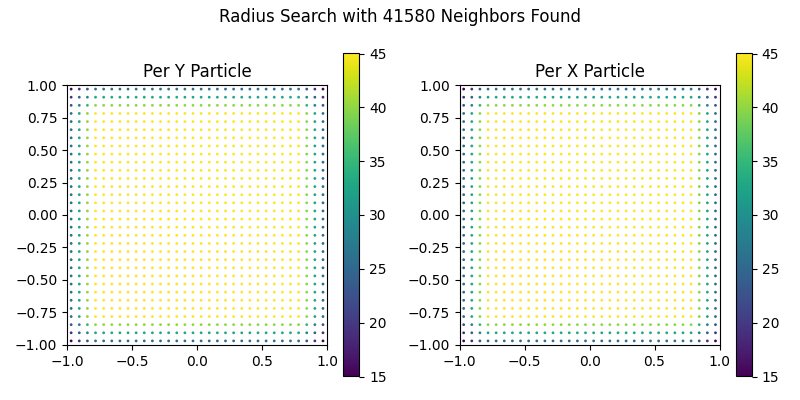

In [7]:

import matplotlib.pyplot as plt

fig, axis = plt.subplots(1,2, figsize = (8,4), squeeze=False)
sc = axis[0,0].scatter(x[:,0].cpu(), x[:,1].cpu(), s = 1, c = nj.cpu().numpy())
axis[0,0].set_aspect('equal')
axis[0,0].set_xlim(domain.min[0].cpu().item(), domain.max[0].cpu().item())
axis[0,0].set_ylim(domain.min[1].cpu().item(), domain.max[1].cpu().item())
axis[0,0].set_title('Per Y Particle')
fig.colorbar(sc, ax = axis[0,0])

sc = axis[0,1].scatter(x[:,0].cpu(), x[:,1].cpu(), s = 1, c = ni.cpu().numpy())
axis[0,1].set_aspect('equal')
axis[0,1].set_xlim(domain.min[0].cpu().item(), domain.max[0].cpu().item())
axis[0,1].set_ylim(domain.min[1].cpu().item(), domain.max[1].cpu().item())
axis[0,1].set_title('Per X Particle')

fig.colorbar(sc, ax = axis[0,1])

fig.suptitle(f'Radius Search with {i.shape[0]} Neighbors Found')
fig.tight_layout()

In [9]:

import torchCompactRadius as tcr
from torchCompactRadius import radiusSearch, volumeToSupport

In [ ]:
adjacencyTCRNaive = radiusSearch(
    PointCloud(queryPositions, querySupports),
    PointCloud(referencePositions + offset, referenceSupports),
    mode = mode, domain = domain, 
    hashMapLength = hashMapLength,
    algorithm = 'naive',
    format = 'coo'
)

print(torch.allclose(torch.sort(adjacencyTCRNaive.row.cpu().to(i.dtype)).values, torch.sort(i.cpu()).values))
print(torch.allclose(torch.sort(adjacencyTCRNaive.col.cpu().to(j.dtype)).values, torch.sort(j.cpu()).values))


True
True


In [ ]:
adjacencyTCRCompact = radiusSearch(
    PointCloud(queryPositions, querySupports),
    PointCloud(referencePositions + offset, referenceSupports),
    mode = mode, domain = domain, 
    hashMapLength = hashMapLength,
    algorithm = 'compact',
    format = 'coo'
)

print(torch.allclose(torch.sort(adjacencyTCRCompact.row.cpu().to(i.dtype)).values, torch.sort(i.cpu()).values))
print(torch.allclose(torch.sort(adjacencyTCRCompact.col.cpu().to(j.dtype)).values, torch.sort(j.cpu()).values))


True
True


In [26]:
def runTCRCompact(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusSearch(
        PointCloud(queryPositions, querySupports),
        PointCloud(referencePositions + offset, referenceSupports),
        mode = mode, domain = domain, 
        hashMapLength = hashMapLength,
        algorithm = 'compact',
        format = 'coo'
    )
    
def runTCRNaive(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusSearch(
        PointCloud(queryPositions, querySupports),
        PointCloud(referencePositions + offset, referenceSupports),
        mode = mode, domain = domain, 
        hashMapLength = hashMapLength,
        algorithm = 'naive',
        format = 'coo'
    )
    
def runNaive(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusNaive(queryPositions, referencePositions, 
                  querySupports, referenceSupports, 
                  domain.periodic, domain.min, domain.max, mode = mode)
    
def runWarpSmall(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return warp_radius_search_small(
    queryPositions, referencePositions + offset, querySupports, referenceSupports, domain.periodic, domain, mode = mode)
    
def runWarpCompact(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusSearchCompactHashMap(
        queryPositions, referencePositions + offset,
        querySupports, referenceSupports,
        periodicity = domain.periodic, domainDescription=domain,
        mode = mode, hashMapLength=hashMapLength
)

In [27]:
import time

def measureTime(fn, queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    initialMemory = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    begin.record()
    
    adjacency = fn(queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength)
    
    end.record()
    torch.cuda.synchronize()
    finalMemory = torch.cuda.memory_allocated()
    maxMemory = torch.cuda.max_memory_allocated()
    cpuEnd = time.time()
    gpuTime = begin.elapsed_time(end)
    cpuTime = cpuEnd - cpuBegin
    
    return adjacency, gpuTime, cpuTime, initialMemory, finalMemory, maxMemory

In [28]:
algorithms = [
    (runTCRCompact, 'compact[TCR]'),
    (runTCRNaive, 'naive[TCR]'),
    (runNaive, 'naive'),
    (runWarpSmall, 'warp_small'),
    (runWarpCompact, 'warp_compact')
]

algorithmsNoNaive = [
    (runTCRCompact, 'compact[TCR]'),
    (runWarpSmall, 'warp_small'),
    (runWarpCompact, 'warp_compact')
]

In [31]:
def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

In [45]:
from tqdm.autonotebook import tqdm


def runBenchmarks(device, targetNumNeighbors, nx, dim, periodic, mode, skipNaive):
    device = torch.device(device)
    numParticles = nx**dim
    hashMapLength = getNextPrime(numParticles)
    periodic = False
    x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

    pointCloud = PointCloud(x, h)
    queryPositions = pointCloud.positions
    querySupports = pointCloud.supports
    referencePositions = pointCloud.positions
    referenceSupports = pointCloud.supports
        
        
    algos = algorithmsNoNaive if skipNaive else algorithms
    benchmarkData = []
    for fn, name in (tq:= tqdm(algos, leave = False)):
        tq.set_description(f'Benchmarking {name}')
        for _ in range(16):        
            adjacency, gpuTime, cpuTime, initialMemory, finalMemory, maxMemory = measureTime(fn,
                queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
            )
            
            benchmarkData.append({
                'iter': _,
                'algorithm': name,
                'gpuTime': gpuTime,
                'cpuTime': cpuTime,
                'initialMemory': initialMemory,
                'finalMemory': finalMemory,
                'maxMemory': maxMemory,
                'nx': nx,
                'numParticles': numParticles,
                'targetNumNeighbors': targetNumNeighbors,
                'dim': dim,
                'periodic': periodic,
            })
            
    return benchmarkData

In [ ]:
numParticles = [2**n for n in range(10, 20)]

overallData = []

for num in (tq := tqdm(numParticles)):
    for dim in (tqd := tqdm([1,2,3], leave = False)):
        tqd.set_description(f'Running Dimension {dim} with {num} Particles')
        nx = int(num ** (1/dim))

        benchmarkData = runBenchmarks('cuda', 50, nx, dim, False, 'gather', skipNaive = num > 2**14)
        overallData.extend(benchmarkData)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

In [47]:
import pandas as pd
import seaborn as sns

In [48]:
dataset = pd.DataFrame(overallData)

display(dataset)

,iter,algorithm,gpuTime,cpuTime,initialMemory,finalMemory,maxMemory,nx,numParticles,targetNumNeighbors,dim,periodic
0,0,compact[TCR],6.470400,0.007278,3430400,4096000,4502528,32,1024,50,2,False
1,1,compact[TCR],9.716736,0.010314,4096000,4761600,5168128,32,1024,50,2,False
2,2,compact[TCR],7.557120,0.008498,4096000,4761600,5168128,32,1024,50,2,False
3,3,compact[TCR],4.705280,0.005161,4096000,4761600,5168128,32,1024,50,2,False
4,4,compact[TCR],11.635680,0.012290,4096000,4761600,5168128,32,1024,50,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1915,11,warp_compact,11.163648,0.011764,3446784,3463168,3551232,32,1024,50,2,False
1916,12,warp_compact,7.399424,0.008106,3446784,3463168,3551232,32,1024,50,2,False
1917,13,warp_compact,8.770560,0.009385,3446784,3463168,3551232,32,1024,50,2,False
1918,14,warp_compact,5.853184,0.006226,3446784,3463168,3551232,32,1024,50,2,False


In [49]:
sns.boxplot(data = dataset, x = 'numParticles', y = 'gpuTime', hue = 'algorithm')

<Axes: title={'center': 'Per X Particle'}, xlabel='numParticles', ylabel='gpuTime'>

In [ ]:
import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *

particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))


simulationState = BasicState(
    positions = particles_l.positions,
    supports = particles_l.supports,
    masses = particles_l.masses,
    densities = particles_l.densities,        
    velocities = torch.zeros_like(referencePositions),
    kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
)

# neighborhood, sparseNeighborhood = buildNeighborhood(simulationState, simulationState, domain, 1.4, 'superSymmetric')
# actualNeighbors = filterNeighborhood(sparseNeighborhood)

from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme


torchCompactRadius not found, using fallback implementations.


/home/winchenbach/dev/diffSPH_pbs/src/diffSPH/util.py:30: UserWarning: No cuda version of the neighbor search is available. [ImportError]
  warnings.warn('No cuda version of the neighbor search is available. [ImportError]')
/home/winchenbach/dev/diffSPH_pbs/src/diffSPH/util.py:47: UserWarning: No Implementation of scatter_max is available. CRKSPH and the Cullen Dehnen Viscosity Switch won't work.
  warnings.warn("No Implementation of scatter_max is available. CRKSPH and the Cullen Dehnen Viscosity Switch won't work.")
/home/winchenbach/dev/diffSPH_pbs/src/diffSPH/neighborhood.py:640: UserWarning: Using fallback implementation for radius search.
  warnings.warn('Using fallback implementation for radius search.')


In [17]:
pos = particles_l.positions.clone()
pos.grad = None
pos.requires_grad = True
simulationState.positions = pos

neighborhood, neighbors = evaluateNeighborhood(simulationState, domainDescription,  KernelType.Wendland4, verletScale =1.4, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
densities = computeDensity(simulationState,  KernelType.Wendland4, neighbors.get('noghost'), SupportScheme.Gather)
print(f"DiffSPH computed densities min: {densities.min()}, max: {densities.max()}, mean: {densities.mean()}")

error = torch.sum((1-densities)**2)
error.backward()


DiffSPH computed densities min: 0.5079768896102905, max: 1.0004249811172485, mean: 0.959396243095398


In [18]:
pos.grad

tensor([[-6.1046, -6.1046],
        [ 0.1369, -5.1247],
        [ 0.7245, -4.1727],
        ...,
        [-0.7245,  4.1727],
        [-0.1369,  5.1247],
        [ 6.1046,  6.1046]])

In [19]:
grad_diff = positionsTemp.grad - pos.grad
print(f'min difference: {torch.min(grad_diff)}, max difference: {torch.max(grad_diff)}')

min difference: -7.152557373046875e-07, max difference: 1.1920928955078125e-06


In [20]:
positionsTemp.grad

tensor([[-6.1046, -6.1046],
        [ 0.1369, -5.1247],
        [ 0.7245, -4.1727],
        ...,
        [-0.7245,  4.1727],
        [-0.1369,  5.1247],
        [ 6.1046,  6.1046]])